# Convolutional Neural Networks - Build Model
---
In this notebook, we build and train a **CNN** to classify images from the CIFAR-10 database. 
* The code provided here are **almost** working. You are required to build up a CNN model and train it.
* Make sure you covered implementations of the **TODO**s in this notebook

The images in this database are small color images that fall into one of ten classes; some example images are pictured below.

<img src='cifar_data.png' width=50% height=50% />

### Optional: Use [CUDA](http://pytorch.org/docs/stable/cuda.html) if Available

Since these are color (32x32x3) images, it may prove useful to speed up your training time by using a GPU. CUDA is a parallel computing platform and CUDA Tensors are the same as typical Tensors, but they utilize GPU's for effcient parallel computation.

In [33]:
import torch
import numpy as np

# check if CUDA is available
train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

CUDA is not available.  Training on CPU ...


## Load the [Data](http://pytorch.org/docs/stable/torchvision/datasets.html)
---
Downloading may take a minute. We load in the training and test data, split the training data into a training and validation set, then create DataLoaders for each of these sets of data.

In [34]:
from torchvision import datasets
import torchvision.transforms as transforms
from torch.utils.data.sampler import SubsetRandomSampler

# number of subprocesses to use for data loading
num_workers = 0
# how many samples per batch to load
batch_size = 20
# percentage of training set to use as validation
valid_size = 0.2

# convert data to a normalized torch.FloatTensor
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

# choose the training and test datasets
train_data = datasets.CIFAR10('data', train=True,
                              download=True, transform=transform)
test_data = datasets.CIFAR10('data', train=False,
                             download=True, transform=transform)

# obtain training indices that will be used for validation
num_train = len(train_data)
indices = list(range(num_train))
np.random.shuffle(indices)
split = int(np.floor(valid_size * num_train))
train_idx, valid_idx = indices[split:], indices[:split]

# define samplers for obtaining training and validation batches
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# prepare data loaders (combine dataset and sampler)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=train_sampler, num_workers=num_workers)
valid_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, 
    sampler=valid_sampler, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, 
    num_workers=num_workers)

# specify the image classes
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

### Visualize a Batch of Training Data

In [35]:
import matplotlib.pyplot as plt
%matplotlib inline

# helper function to un-normalize and display an image
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    plt.imshow(np.transpose(img, (1, 2, 0)))  # convert from Tensor image

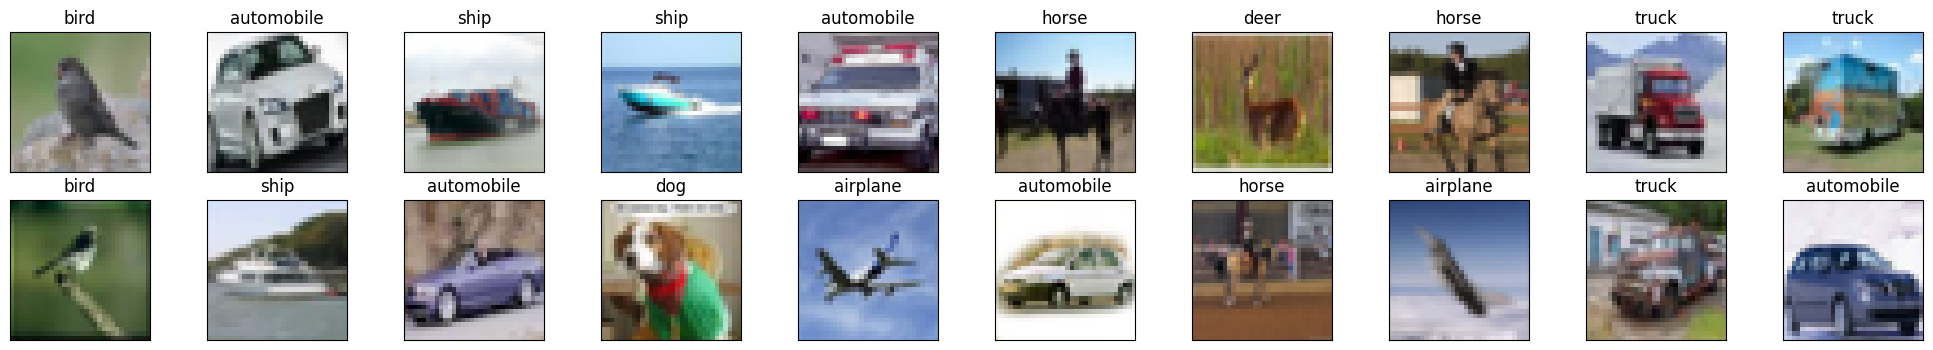

In [36]:
# obtain one batch of training images
dataiter = iter(train_loader)
#images, labels = dataiter.next() #python, torchvision version match issue
images, labels = next(dataiter)
images = images.numpy() # convert images to numpy for display

# plot the images in the batch, along with the corresponding labels
fig = plt.figure(figsize=(25, 4))
# display 20 images
for idx in np.arange(20):
    ax = fig.add_subplot(2, int(20/2), idx+1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title(classes[labels[idx]])

### View an Image in More Detail

Here, we look at the normalized red, green, and blue (RGB) color channels as three separate, grayscale intensity images.

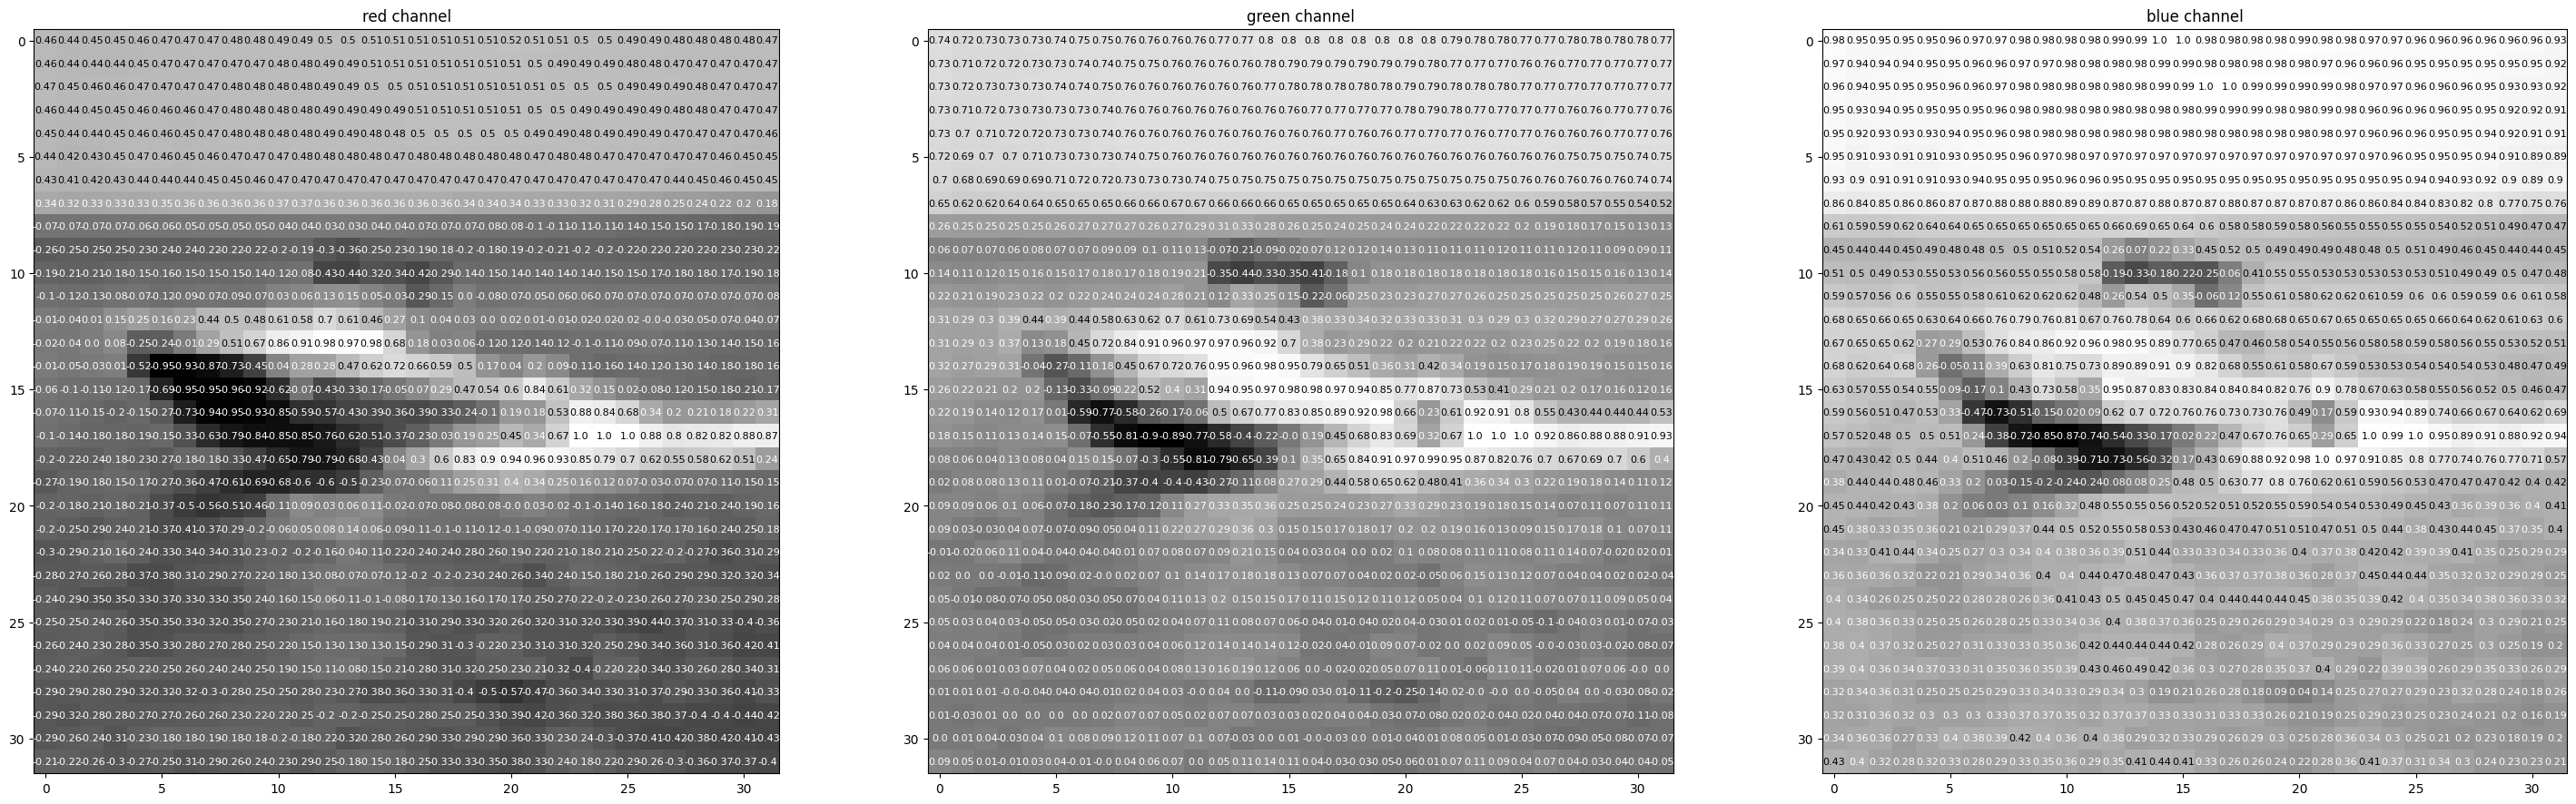

In [37]:
rgb_img = np.squeeze(images[3])
channels = ['red channel', 'green channel', 'blue channel']

fig = plt.figure(figsize = (36, 36)) 
for idx in np.arange(rgb_img.shape[0]):
    ax = fig.add_subplot(1, 3, idx + 1)
    img = rgb_img[idx]
    ax.imshow(img, cmap='gray')
    ax.set_title(channels[idx])
    width, height = img.shape
    thresh = img.max()/2.5
    for x in range(width):
        for y in range(height):
            val = round(img[x][y],2) if img[x][y] !=0 else 0
            ax.annotate(str(val), xy=(y,x),
                    horizontalalignment='center',
                    verticalalignment='center', size=8,
                    color='white' if img[x][y]<thresh else 'black')

## **TODO**: Define the Network [Architecture](http://pytorch.org/docs/stable/nn.html)
---
Build up your own Convolutional Neural Network using Pytorch API:
- nn.Conv2d(): for convolution
- nn.MaxPool2d(): for maxpooling (spatial resolution reduction)
- nn.Linear(): for last 1 or 2 layers of fully connected layer before the output layer.
- nn.Dropout(): optional, [dropout](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html) can be used to avoid overfitting.
- F.relu(): Use ReLU as the activation function for all the hidden layers

The following is a skeleton example that's not completely working. 

In [38]:
import torch.nn as nn
import torch.nn.functional as F

# define the CNN architecture
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        
        # Convolutional layers
        # Input: 32x32x3 (CIFAR-10 images)
        # Conv1: 3 input channels, 32 output channels, 3x3 kernel
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)  # Output: 32x32x32
        # After pool: 16x16x32
        
        # Conv2: 32 input channels, 64 output channels, 3x3 kernel
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)  # Output: 16x16x64
        # After pool: 8x8x64
        
        # Conv3: 64 input channels, 128 output channels, 3x3 kernel
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)  # Output: 8x8x128
        # After pool: 4x4x128
        
        # max pooling layer
        self.pool = nn.MaxPool2d(2, 2)
        
        # Fully connected layers
        # After 3 pooling layers: 4x4x128 = 2048
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 10)  # 10 classes in CIFAR-10

        # dropout layer (p=0.25)
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        # add sequence of convolutional and max pooling layers
        # Conv1 -> ReLU -> Pool
        x = self.pool(F.relu(self.conv1(x)))  # 32x32x32 -> 16x16x32
        
        # Conv2 -> ReLU -> Pool
        x = self.pool(F.relu(self.conv2(x)))  # 16x16x64 -> 8x8x64
        
        # Conv3 -> ReLU -> Pool
        x = self.pool(F.relu(self.conv3(x)))  # 8x8x128 -> 4x4x128

        # Flatten x to feed into fully connected layer
        x = x.view(-1, 128 * 4 * 4)  # Flatten to [batch_size, 2048]

        # add dropout layer
        x = self.dropout(x)
        
        # add 1st hidden layer, with relu activation function
        x = F.relu(self.fc1(x))
        
        # add dropout layer
        x = self.dropout(x)
        
        # add 2nd hidden layer (output layer, no activation here)
        x = self.fc2(x)
        return x

# create a complete CNN
model = Net()
print(model)

# move tensors to GPU if CUDA is available
if train_on_gpu:
    model.cuda()

Net(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)


### Specify [Loss Function](http://pytorch.org/docs/stable/nn.html#loss-functions) and [Optimizer](http://pytorch.org/docs/stable/optim.html)
---
Decide on a loss and optimization function that is best suited for this classification task. The linked code examples from above, may be a good starting point; [this PyTorch classification example](https://github.com/pytorch/tutorials/blob/master/beginner_source/blitz/cifar10_tutorial.py) Pay close attention to the value for **learning rate** as this value determines how your model converges to a small error.

The following is working code, but you can make your own adjustments.

**TODO**: try to compare with ADAM optimizer

In [39]:
import torch.optim as optim

# specify loss function (categorical cross-entropy)
criterion = nn.CrossEntropyLoss()

# specify optimizer - using Adam optimizer (better than SGD for most cases)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Alternative: SGD optimizer (uncomment to compare)
# optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

## Train the Network
---
Remember to look at how the training and validation loss decreases over time; if the validation loss ever increases it indicates possible overfitting.

The following is working code, but you are encouraged to make your own adjustments and enhance the implementation.

In [40]:
# number of epochs to train the model - increased for better accuracy
n_epochs = 25

valid_loss_min = np.Inf # track change in validation loss

# Lists to store losses for plotting
train_losses = []
valid_losses = []

for epoch in range(1, n_epochs+1):

    # keep track of training and validation loss
    train_loss = 0.0
    valid_loss = 0.0
    
    ###################
    # train the model #
    ###################
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        # move tensors to GPU if CUDA is available
        if train_on_gpu:
            data, target = data.cuda(), target.cuda()
        # clear the gradients of all optimized variables
        optimizer.zero_grad()
        # forward pass: compute predicted outputs by passing inputs to the model
        output = model(data)
        # calculate the batch loss
        loss = criterion(output, target)
        # backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()
        # perform a single optimization step (parameter update)
        optimizer.step()
        # update training loss
        train_loss += loss.item()*data.size(0)
        
    ######################    
    # validate the model #
    ######################
    model.eval()
    for batch_idx, (data, target) in enumerate(valid_loader):
        # move tensors to GPU if CUDA is available
        if train_on_gpu:
            data, target = data.cuda(), target.cuda()
        # forward pass: compute predicted outputs by passing inputs to the model
        output = model(data)
        # calculate the batch loss
        loss = criterion(output, target)
        # update average validation loss 
        valid_loss += loss.item()*data.size(0)
    
    # calculate average losses
    train_loss = train_loss/len(train_loader.sampler)
    valid_loss = valid_loss/len(valid_loader.sampler)
    
    # Store losses for plotting
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
        
    # print training/validation statistics 
    print('Epoch: {} \tTraining Loss: {:.6f} \tValidation Loss: {:.6f}'.format(
        epoch, train_loss, valid_loss))
    
    # save model if validation loss has decreased
    if valid_loss <= valid_loss_min:
        print('Validation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(
        valid_loss_min,
        valid_loss))
        torch.save(model.state_dict(), 'model_trained.pt')
        valid_loss_min = valid_loss

Epoch: 1 	Training Loss: 1.420599 	Validation Loss: 1.085251
Validation loss decreased (inf --> 1.085251).  Saving model ...
Epoch: 2 	Training Loss: 1.018264 	Validation Loss: 0.889011
Validation loss decreased (1.085251 --> 0.889011).  Saving model ...
Epoch: 3 	Training Loss: 0.855501 	Validation Loss: 0.823239
Validation loss decreased (0.889011 --> 0.823239).  Saving model ...
Epoch: 4 	Training Loss: 0.755290 	Validation Loss: 0.786230
Validation loss decreased (0.823239 --> 0.786230).  Saving model ...
Epoch: 5 	Training Loss: 0.683249 	Validation Loss: 0.738244
Validation loss decreased (0.786230 --> 0.738244).  Saving model ...
Epoch: 6 	Training Loss: 0.610751 	Validation Loss: 0.729037
Validation loss decreased (0.738244 --> 0.729037).  Saving model ...
Epoch: 7 	Training Loss: 0.570110 	Validation Loss: 0.712457
Validation loss decreased (0.729037 --> 0.712457).  Saving model ...
Epoch: 8 	Training Loss: 0.519063 	Validation Loss: 0.750374
Epoch: 9 	Training Loss: 0.482239 

### Plot Training and Validation Loss Curves

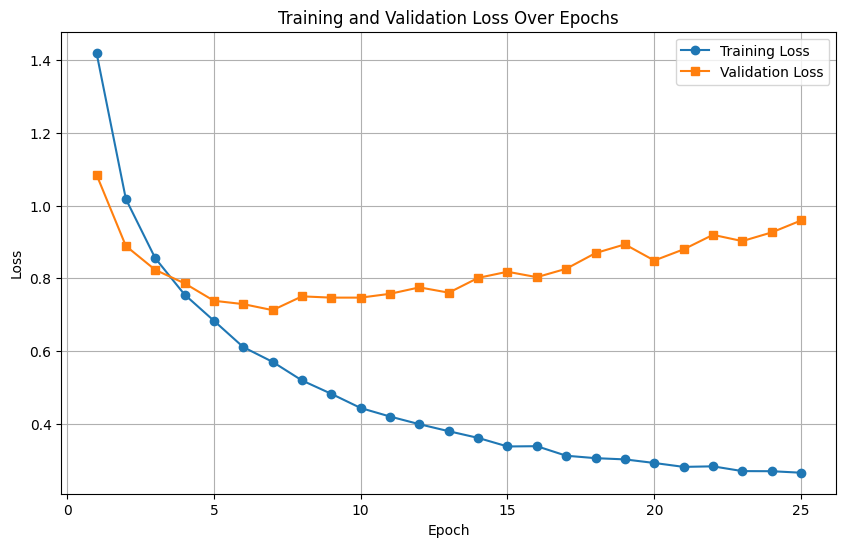

In [41]:
# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_epochs+1), train_losses, label='Training Loss', marker='o')
plt.plot(range(1, n_epochs+1), valid_losses, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

###  Load the Model with the Lowest Validation Loss
This is the model we will use for testing, which is the model we saved in the last step

In [42]:
model.load_state_dict(torch.load('model_trained.pt'))

<All keys matched successfully>

## Test the Trained Network
---
Test your trained model on previously unseen data! Remember we have downloaded `train_data` and `test_data`. We will use `test_data` through `test_loader`.

A "good" result will be a CNN that gets around 70% (or more, try your best!) accuracy on these test images.

The following is working code, but you are encouraged to make your own adjustments and enhance the implementation.

In [43]:
# track test loss
test_loss = 0.0
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

model.eval()
# iterate over test data
for batch_idx, (data, target) in enumerate(test_loader):
    # move tensors to GPU if CUDA is available
    if train_on_gpu:
        data, target = data.cuda(), target.cuda()
    # forward pass: compute predicted outputs by passing inputs to the model
    output = model(data)
    # calculate the batch loss
    loss = criterion(output, target)
    # update test loss 
    test_loss += loss.item()*data.size(0)
    # convert output probabilities to predicted class
    _, pred = torch.max(output, 1)    
    # compare predictions to true label
    correct_tensor = pred.eq(target.data.view_as(pred))
    correct = np.squeeze(correct_tensor.numpy()) if not train_on_gpu else np.squeeze(correct_tensor.cpu().numpy())
    # calculate test accuracy for each object class
    for i in range(batch_size):
        label = target.data[i]
        class_correct[label] += correct[i].item()
        class_total[label] += 1

# average test loss
test_loss = test_loss/len(test_loader.dataset)
print('Test Loss: {:.6f}\n'.format(test_loss))

for i in range(10):
    if class_total[i] > 0:
        print('Test Accuracy of %5s: %2d%% (%2d/%2d)' % (
            classes[i], 100 * class_correct[i] / class_total[i],
            np.sum(class_correct[i]), np.sum(class_total[i])))
    else:
        print('Test Accuracy of %5s: N/A (no training examples)' % (classes[i]))

print('\nTest Accuracy (Overall): %2d%% (%2d/%2d)' % (
    100. * np.sum(class_correct) / np.sum(class_total),
    np.sum(class_correct), np.sum(class_total)))

Test Loss: 0.723066

Test Accuracy of airplane: 77% (774/1000)
Test Accuracy of automobile: 88% (886/1000)
Test Accuracy of  bird: 52% (529/1000)
Test Accuracy of   cat: 51% (517/1000)
Test Accuracy of  deer: 73% (731/1000)
Test Accuracy of   dog: 73% (735/1000)
Test Accuracy of  frog: 85% (858/1000)
Test Accuracy of horse: 82% (824/1000)
Test Accuracy of  ship: 85% (859/1000)
Test Accuracy of truck: 82% (823/1000)

Test Accuracy (Overall): 75% (7536/10000)


### Visualize Sample Test Results

The following is working code, but you are encouraged to make your own adjustments and enhance the visualization.

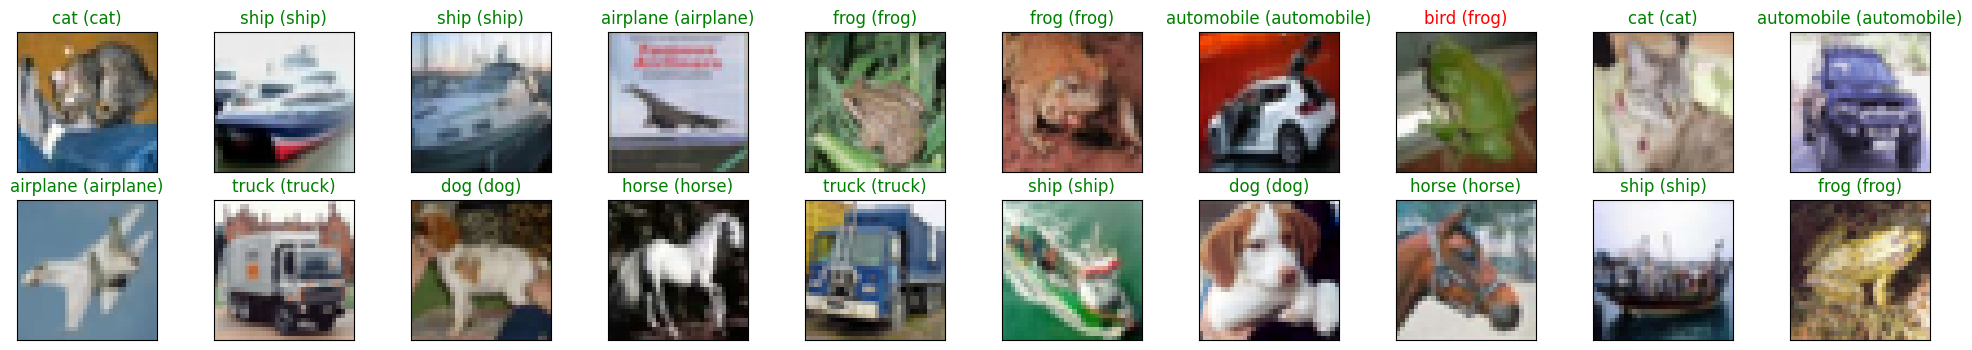

In [44]:
# obtain one batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)
images.numpy()

# move model inputs to cuda, if GPU available
if train_on_gpu:
    images = images.cuda()

# get sample outputs
output = model(images)
# convert output probabilities to predicted class
_, preds_tensor = torch.max(output, 1)
preds = np.squeeze(preds_tensor.numpy()) if not train_on_gpu else np.squeeze(preds_tensor.cpu().numpy())

# plot the images in the batch, along with predicted and true labels
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, int(20/2), idx+1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title("{} ({})".format(classes[preds[idx]], classes[labels[idx]]),
                 color=("green" if preds[idx]==labels[idx].item() else "red"))

# Task 2: Feature Map Visualization
---
## Part A: Visualize Feature Maps from First Convolutional Layer

Selected images from classes: ['cat', 'ship', 'airplane']


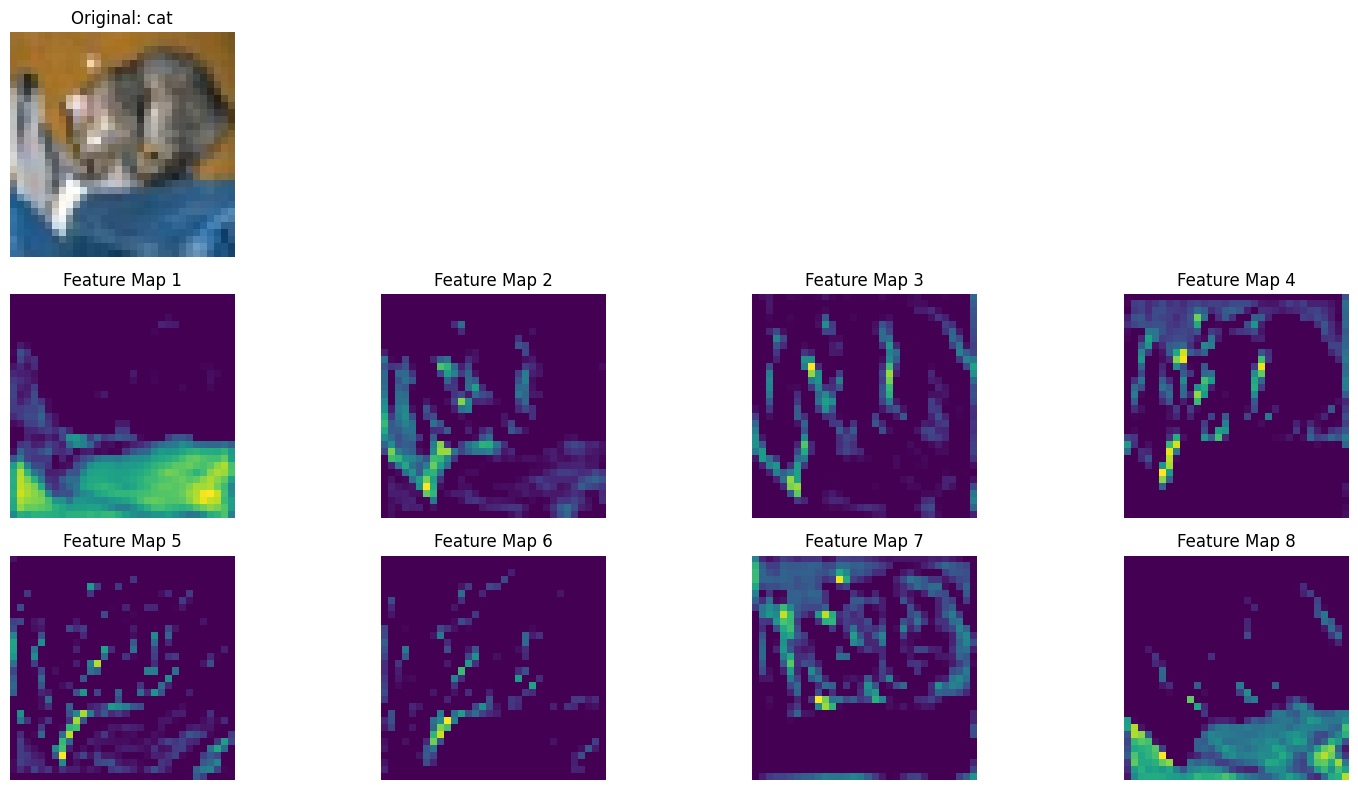


Class: cat
Feature maps shape: torch.Size([32, 32, 32])
--------------------------------------------------------------------------------


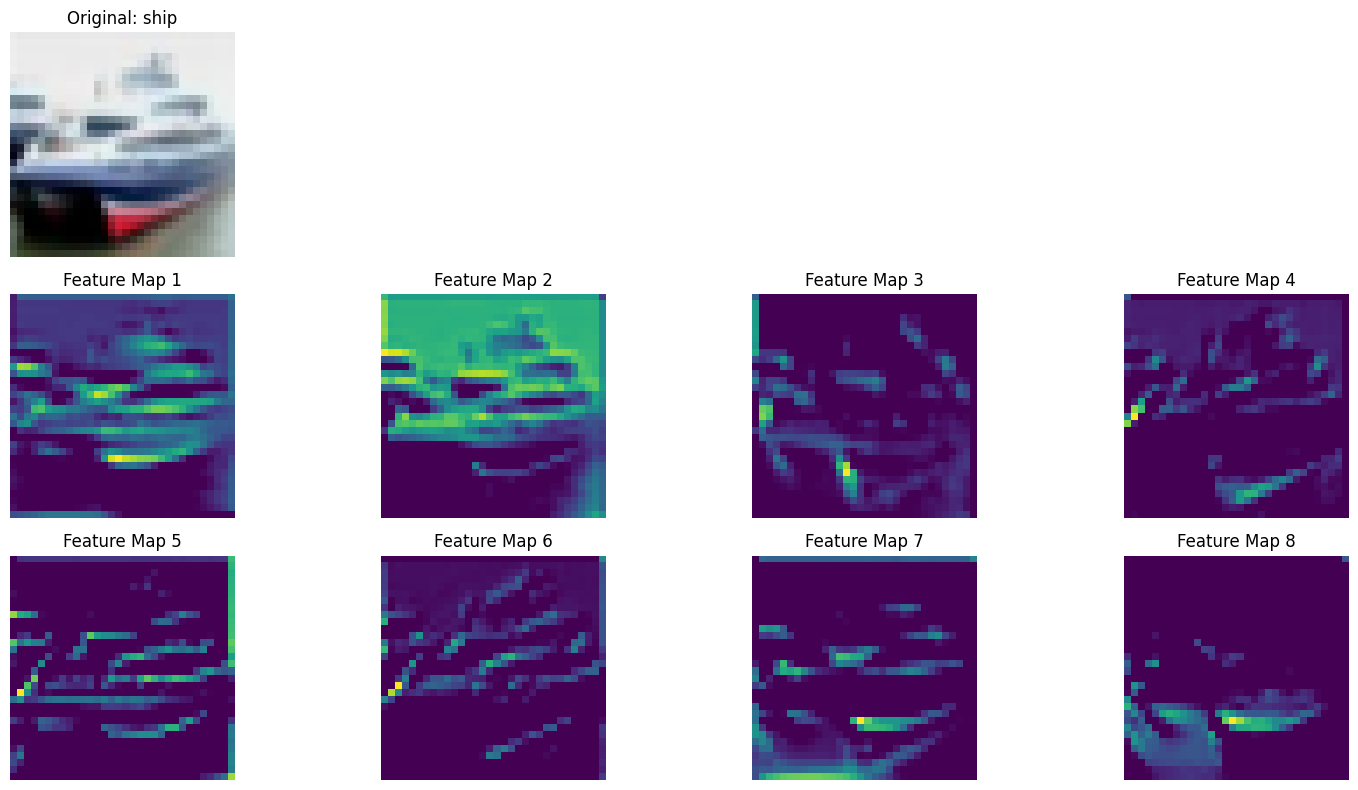


Class: ship
Feature maps shape: torch.Size([32, 32, 32])
--------------------------------------------------------------------------------


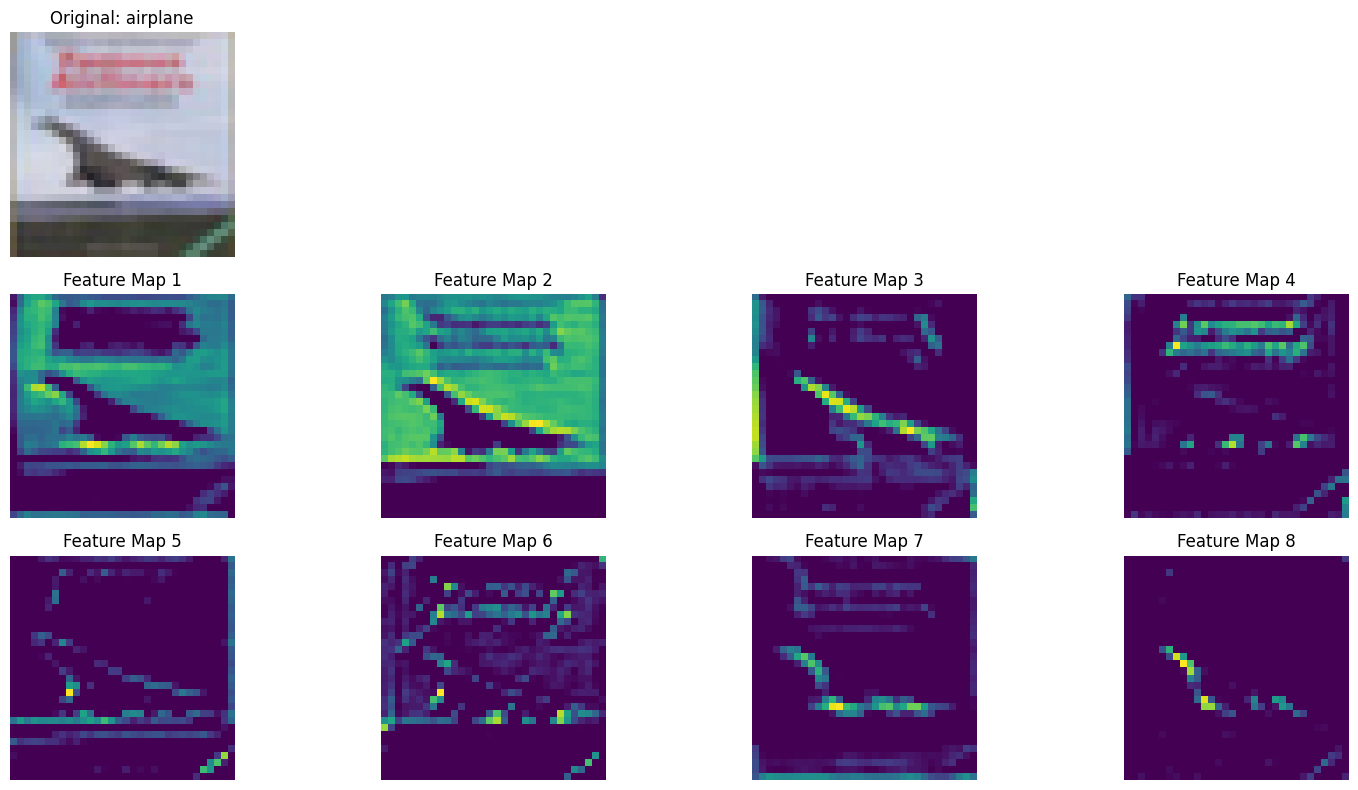


Class: airplane
Feature maps shape: torch.Size([32, 32, 32])
--------------------------------------------------------------------------------


In [45]:
# Select 3 test images from different classes
dataiter = iter(test_loader)
test_images, test_labels = next(dataiter)

# Select 3 images from different classes
selected_indices = []
selected_classes = []
for i in range(len(test_labels)):
    if test_labels[i].item() not in selected_classes:
        selected_indices.append(i)
        selected_classes.append(test_labels[i].item())
    if len(selected_indices) == 3:
        break

print(f"Selected images from classes: {[classes[test_labels[i].item()] for i in selected_indices]}")

# Function to extract feature maps from first conv layer
def get_first_layer_feature_maps(model, image):
    """
    Extract feature maps from the first convolutional layer
    """
    model.eval()
    with torch.no_grad():
        if train_on_gpu:
            image = image.cuda()
        # Pass through first conv layer and apply ReLU
        x = F.relu(model.conv1(image.unsqueeze(0)))
    return x.squeeze(0).cpu()

# Visualize feature maps for each selected image
for idx in selected_indices:
    image = test_images[idx]
    label = test_labels[idx].item()
    
    # Get feature maps
    feature_maps = get_first_layer_feature_maps(model, image)
    
    # Plot original image and 8 feature maps
    fig = plt.figure(figsize=(15, 8))
    
    # Original image
    ax = fig.add_subplot(3, 4, 1)
    imshow(image)
    ax.set_title(f'Original: {classes[label]}')
    ax.axis('off')
    
    # Plot 8 feature maps
    for i in range(8):
        ax = fig.add_subplot(3, 4, i+5)
        ax.imshow(feature_maps[i], cmap='viridis')
        ax.set_title(f'Feature Map {i+1}')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nClass: {classes[label]}")
    print(f"Feature maps shape: {feature_maps.shape}")
    print("-" * 80)

## Part B: Maximally Activating Images for Selected Filters

We will select 3 filters from the second convolutional layer and find the top 5 test images that produce the highest activation for each filter. We define activation as the **mean value** of the feature map (overall response strength).

In [46]:
# Function to get activations for a specific filter in conv2
def get_filter_activation(model, image, layer_name='conv2', filter_idx=0):
    """
    Get the activation value for a specific filter.
    Activation is defined as the mean value of the feature map after ReLU.
    """
    model.eval()
    with torch.no_grad():
        if train_on_gpu:
            image = image.cuda()
        
        # Forward pass through layers up to conv2
        x = image.unsqueeze(0)
        x = model.pool(F.relu(model.conv1(x)))  # After conv1 and pool
        
        if layer_name == 'conv2':
            x = F.relu(model.conv2(x))  # After conv2, before pool
            # Get the specific filter's feature map
            feature_map = x[0, filter_idx, :, :]
            # Return mean activation
            return feature_map.mean().cpu().item()
    
    return 0.0

# Select 3 filters from conv2 (indices 0, 15, 31)
selected_filters = [0, 15, 31]

# Calculate activations for all test images for each filter
print("Calculating activations for all test images...")
filter_activations = {f: [] for f in selected_filters}

for batch_idx, (images, labels) in enumerate(test_loader):
    for img_idx in range(len(images)):
        image = images[img_idx]
        label = labels[img_idx].item()
        
        for filter_idx in selected_filters:
            activation = get_filter_activation(model, image, 'conv2', filter_idx)
            filter_activations[filter_idx].append({
                'activation': activation,
                'image': image,
                'label': label,
                'batch_idx': batch_idx,
                'img_idx': img_idx
            })
    
    if batch_idx % 100 == 0:
        print(f"Processed {batch_idx}/{len(test_loader)} batches")

print("Done calculating activations!")

Calculating activations for all test images...
Processed 0/500 batches
Processed 100/500 batches
Processed 200/500 batches
Processed 300/500 batches
Processed 400/500 batches
Done calculating activations!



Filter 0 in Conv2 - Top 5 Maximally Activating Images


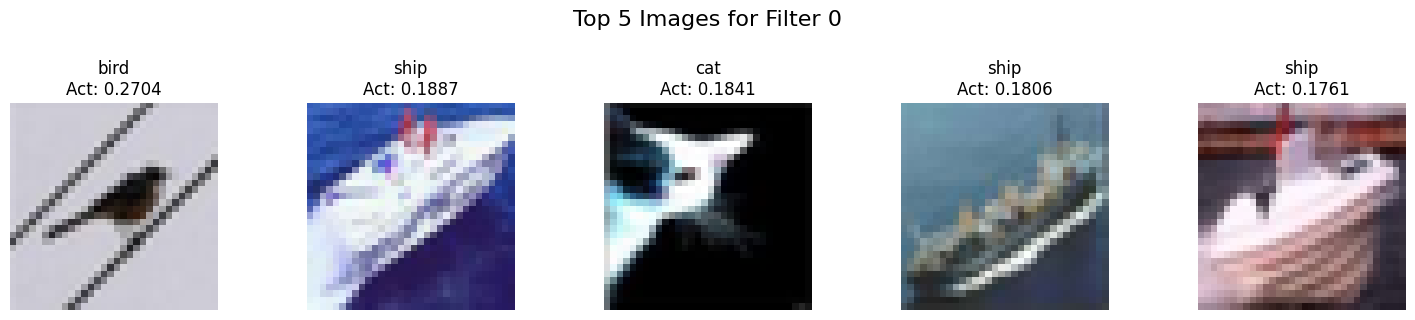


Top 5 activation values: ['0.2704', '0.1887', '0.1841', '0.1806', '0.1761']
Classes: ['bird', 'ship', 'cat', 'ship', 'ship']
Class distribution: {'bird': 1, 'ship': 3, 'cat': 1}

Filter 15 in Conv2 - Top 5 Maximally Activating Images


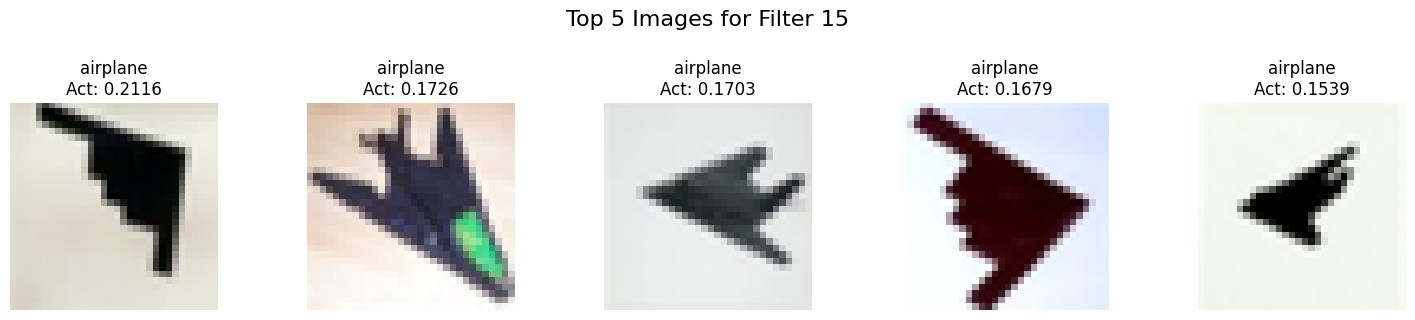


Top 5 activation values: ['0.2116', '0.1726', '0.1703', '0.1679', '0.1539']
Classes: ['airplane', 'airplane', 'airplane', 'airplane', 'airplane']
Class distribution: {'airplane': 5}

Filter 31 in Conv2 - Top 5 Maximally Activating Images


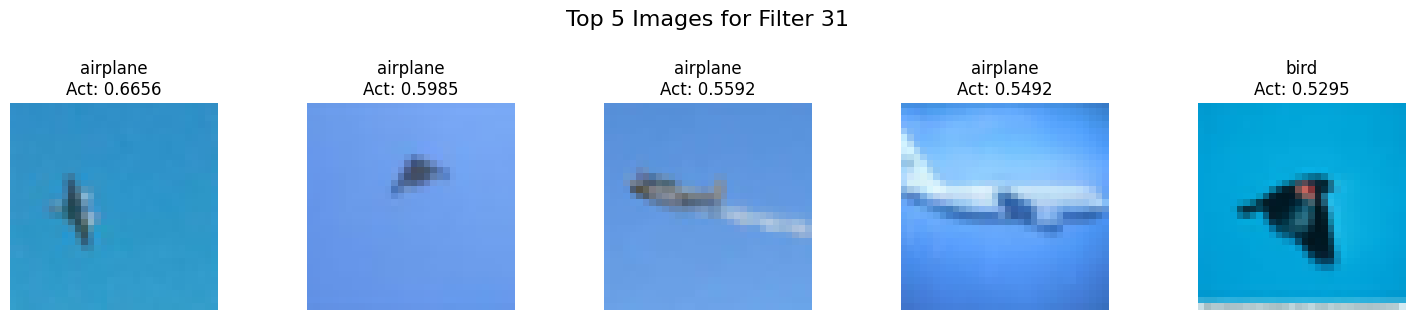


Top 5 activation values: ['0.6656', '0.5985', '0.5592', '0.5492', '0.5295']
Classes: ['airplane', 'airplane', 'airplane', 'airplane', 'bird']
Class distribution: {'airplane': 4, 'bird': 1}


In [47]:
# For each filter, find top 5 maximally activating images
for filter_idx in selected_filters:
    print(f"\n{'='*80}")
    print(f"Filter {filter_idx} in Conv2 - Top 5 Maximally Activating Images")
    print(f"{'='*80}")
    
    # Sort by activation value
    sorted_activations = sorted(filter_activations[filter_idx], 
                               key=lambda x: x['activation'], 
                               reverse=True)
    
    # Get top 5
    top_5 = sorted_activations[:5]
    
    # Plot the top 5 images
    fig = plt.figure(figsize=(15, 3))
    for i, item in enumerate(top_5):
        ax = fig.add_subplot(1, 5, i+1)
        imshow(item['image'])
        ax.set_title(f"{classes[item['label']]}\nAct: {item['activation']:.4f}")
        ax.axis('off')
    
    plt.suptitle(f'Top 5 Images for Filter {filter_idx}', fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    activation_values = [f"{item['activation']:.4f}" for item in top_5]
    print(f"\nTop 5 activation values: {activation_values}")
    print(f"Classes: {[classes[item['label']] for item in top_5]}")
    
    # Count class distribution
    class_counts = {}
    for item in top_5:
        class_name = classes[item['label']]
        class_counts[class_name] = class_counts.get(class_name, 0) + 1
    print(f"Class distribution: {class_counts}")

## Summary and Model Architecture Details

**Model Architecture:**
- 3 Convolutional Layers (Conv1: 32 filters, Conv2: 64 filters, Conv3: 128 filters)
- MaxPooling after each conv layer (2x2)
- 2 Fully Connected Layers (FC1: 512 units, FC2: 10 units)
- Dropout (p=0.25) for regularization
- ReLU activations throughout

**Training Setup:**
- Loss Function: CrossEntropyLoss
- Optimizer: Adam (lr=0.001)
- Batch Size: 20
- Epochs: 25
- Validation Split: 20%

**Activation Definition for Part B:**
We used the **mean value** of each filter's feature map as the activation metric.